# Lesson 9: Dipoles fitting

Neurocampus course "Signals of the whole brain"

Daria Kleeva

dkleeva@gmail.com

May 13th, 2026


In [ ]:
# !pip3 install nilearn

In [1]:
import mne
from mne.datasets import sample
import numpy as np
from os import path as op
from mne.forward import make_forward_dipole
from mne.evoked import combine_evoked
from mne.simulation import simulate_evoked
from matplotlib import pyplot as plt
from nilearn.plotting import plot_anat
from nilearn.datasets import load_mni152_template

/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Dipoles orientations

In [2]:
data_path = sample.data_path()
meg_path = data_path / 'MEG' / 'sample'
evokeds = mne.read_evokeds(meg_path / 'sample_audvis-ave.fif')
left_auditory = evokeds[0].apply_baseline()
fwd = mne.read_forward_solution(
    meg_path / 'sample_audvis-meg-eeg-oct-6-fwd.fif')
mne.convert_forward_solution(fwd, surf_ori=True, copy=False)
noise_cov = mne.read_cov(meg_path / 'sample_audvis-cov.fif')
subject = 'sample'
subjects_dir = data_path / 'subjects'
trans_fname = meg_path / 'sample_audvis_raw-trans.fif'

Reading /Users/dkleeva/mne_data/MNE-sample-data/MEG/sample/sample_audvis-ave.fif ...
    Read a total of 4 projection items:
        PCA-v1 (1 x 102) active
        PCA-v2 (1 x 102) active
        PCA-v3 (1 x 102) active
        Average EEG reference (1 x 60) active
    Found the data of interest:
        t =    -199.80 ...     499.49 ms (Left Auditory)
        0 CTF compensation matrices available
        nave = 55 - aspect type = 100
Projections have already been applied. Setting proj attribute to True.
No baseline correction applied
    Read a total of 4 projection items:
        PCA-v1 (1 x 102) active
        PCA-v2 (1 x 102) active
        PCA-v3 (1 x 102) active
        Average EEG reference (1 x 60) active
    Found the data of interest:
        t =    -199.80 ...     499.49 ms (Right Auditory)
        0 CTF compensation matrices available
        nave = 61 - aspect type = 100
Projections have already been applied. Setting proj attribute to True.
No baseline correction applied


In [3]:
lh = fwd['src'][0]
verts = lh['rr'] 
tris = lh['tris']
dip_pos = lh['rr'][lh['vertno']] 
dip_ori = lh['nn'][lh['vertno']]
dip_len = len(dip_pos)
dip_times = [0]
white = (1.0, 1.0, 1.0)  
actual_amp = np.ones(dip_len) 
actual_gof = np.ones(dip_len)  
dipoles = mne.Dipole(dip_times, dip_pos, actual_amp, dip_ori, actual_gof)
trans = mne.read_trans(trans_fname)

fig = mne.viz.create_3d_figure(size=(600, 400), bgcolor=white)
coord_frame = 'mri'

mne.viz.plot_alignment(
    subject=subject, subjects_dir=subjects_dir, trans=trans, surfaces='white',
    coord_frame=coord_frame, fig=fig)

mne.viz.plot_dipole_locations(
    dipoles=dipoles, trans=trans, mode='sphere', subject=subject,
    subjects_dir=subjects_dir, coord_frame=coord_frame, scale=7e-4, fig=fig)

mne.viz.set_3d_view(figure=fig, azimuth=180, distance=0.25)

Using pyvistaqt 3d backend.
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


In [4]:
fig = mne.viz.create_3d_figure(size=(600, 400))


mne.viz.plot_alignment(
    subject=subject, subjects_dir=subjects_dir, trans=trans,
    surfaces='white', coord_frame='head', fig=fig)


mne.viz.plot_dipole_locations(
    dipoles=dipoles, trans=trans, mode='arrow', subject=subject,
    subjects_dir=subjects_dir, coord_frame='head', scale=7e-4, fig=fig)

mne.viz.set_3d_view(figure=fig, azimuth=180, distance=0.1)

For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


In [5]:
fig = mne.viz.create_3d_figure(size=(600, 400))

mne.viz.plot_alignment(
    subject=subject, subjects_dir=subjects_dir, trans=trans,
    surfaces='white', coord_frame='head', fig=fig)

mne.viz.plot_alignment(
    subject=subject, subjects_dir=subjects_dir, trans=trans, fwd=fwd,
    surfaces='white', coord_frame='head', fig=fig)

mne.viz.set_3d_view(figure=fig, azimuth=180, distance=0.1)

For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


## Process evoked data

In [6]:
data_path = mne.datasets.sample.data_path()
subjects_dir = op.join(data_path, 'subjects')
fname_ave = op.join(data_path, 'MEG', 'sample', 'sample_audvis-ave.fif')
fname_cov = op.join(data_path, 'MEG', 'sample', 'sample_audvis-cov.fif')
fname_bem = op.join(subjects_dir, 'sample', 'bem', 'sample-5120-bem-sol.fif')
fname_trans = op.join(data_path, 'MEG', 'sample',
                      'sample_audvis_raw-trans.fif')
fname_surf_lh = op.join(subjects_dir, 'sample', 'surf', 'lh.white')
from mne.beamformer import rap_music
from mne.viz import plot_dipole_locations, plot_dipole_amplitudes
from mne.datasets import sample

In [7]:
evoked = mne.read_evokeds(fname_ave, condition='Right Auditory',
                          baseline=(None, 0))

Reading /Users/dkleeva/mne_data/MNE-sample-data/MEG/sample/sample_audvis-ave.fif ...
    Read a total of 4 projection items:
        PCA-v1 (1 x 102) active
        PCA-v2 (1 x 102) active
        PCA-v3 (1 x 102) active
        Average EEG reference (1 x 60) active
    Found the data of interest:
        t =    -199.80 ...     499.49 ms (Right Auditory)
        0 CTF compensation matrices available
        nave = 61 - aspect type = 100
Projections have already been applied. Setting proj attribute to True.
Applying baseline correction (mode: mean)


In [8]:
evoked

<Evoked | 'Right Auditory' (average, N=61), -0.1998 – 0.49949 s, baseline -0.199795 – 0 s, 376 ch, ~4.5 MB>

Projections have already been applied. Setting proj attribute to True.


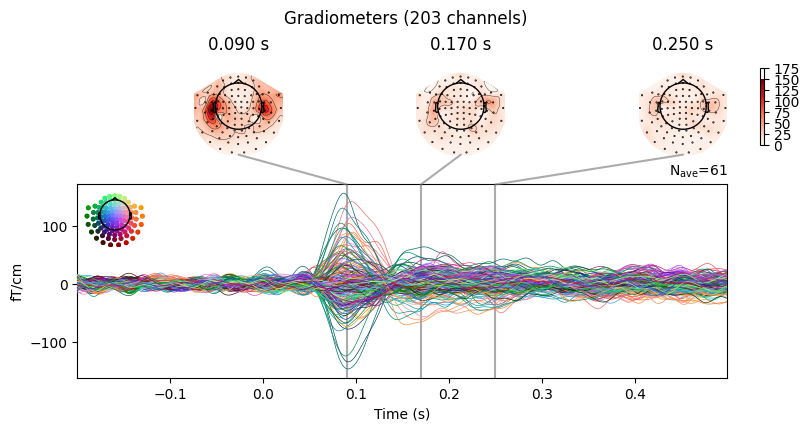

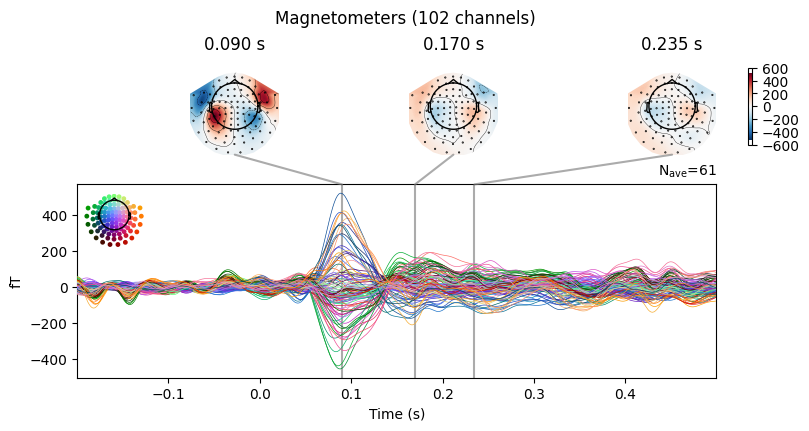

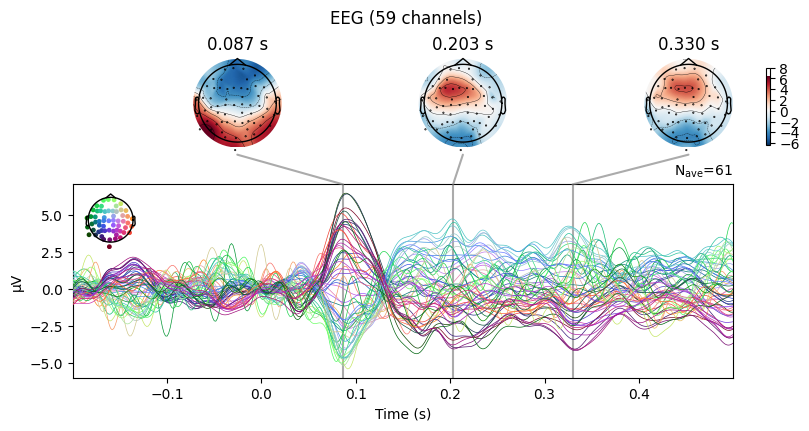

In [9]:
fig = evoked.plot_joint()

In [10]:
evoked.pick_types(meg=True, eeg=False)
evoked_full = evoked.copy()
evoked.crop(0.07, 0.08)

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


<Evoked | 'Right Auditory' (average, N=61), 0.069928 – 0.079918 s, baseline -0.199795 – 0 s (baseline period was cropped after baseline correction), 305 ch, ~3.2 MB>

In [11]:
evoked.crop(0.07, 0.08)

/var/folders/x7/j3l1lskn5hs7tzf40r9kb7qh0000gn/T/ipykernel_58447/1516779454.py:1: RuntimeWarning: tmax is not in time interval. tmax is set to <class 'mne.evoked.Evoked'>.tmax (0.0799181 s)
  evoked.crop(0.07, 0.08)


<Evoked | 'Right Auditory' (average, N=61), 0.069928 – 0.079918 s, baseline -0.199795 – 0 s (baseline period was cropped after baseline correction), 305 ch, ~3.2 MB>

Projections have already been applied. Setting proj attribute to True.


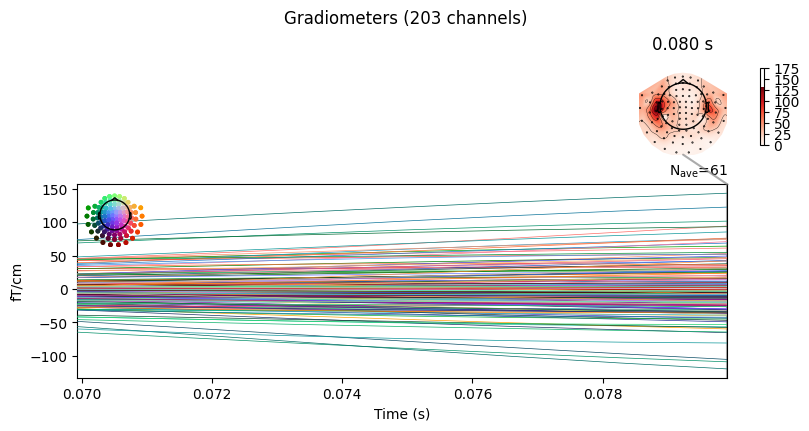

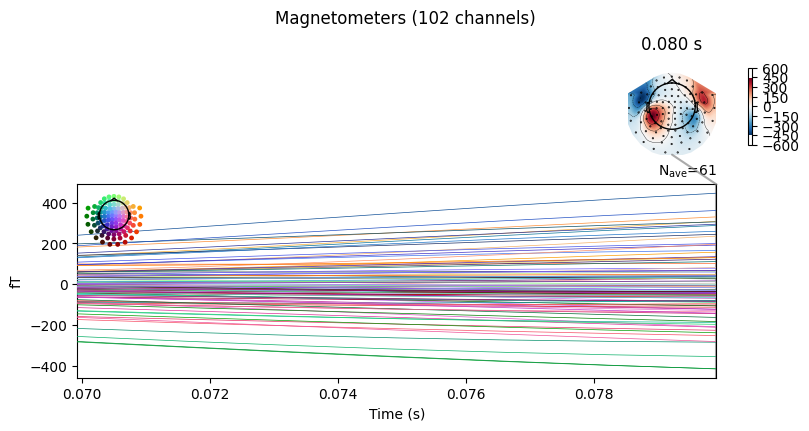

In [12]:
fig = evoked.plot_joint()

## Standard dipole fitting

In [13]:
dip = mne.fit_dipole(evoked, fname_cov, fname_bem, fname_trans)

MRI transform     : /Users/dkleeva/mne_data/MNE-sample-data/MEG/sample/sample_audvis_raw-trans.fif
Head origin       :   -4.3   18.4   67.0 mm rad =   71.8 mm.
Guess grid        :   20.0 mm
Guess mindist     :    5.0 mm
Guess exclude     :   20.0 mm
Using normal MEG coil definitions.
Noise covariance  : /Users/dkleeva/mne_data/MNE-sample-data/MEG/sample/sample_audvis-cov.fif

Coordinate transformation: MRI (surface RAS) -> head
    0.999310 0.009985 -0.035787      -3.17 mm
    0.012759 0.812405 0.582954       6.86 mm
    0.034894 -0.583008 0.811716      28.88 mm
    0.000000 0.000000 0.000000       1.00
Coordinate transformation: MEG device -> head
    0.991420 -0.039936 -0.124467      -6.13 mm
    0.060661 0.984012 0.167456       0.06 mm
    0.115790 -0.173570 0.977991      64.74 mm
    0.000000 0.000000 0.000000       1.00
0 bad channels total
Read 305 MEG channels from info
105 coil definitions read
Coordinate transformation: MEG device -> head
    0.991420 -0.039936 -0.124467      

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.1s finished


[done 156 sources]


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]

---- Fitted :    69.9 ms, distance to inner skull : 10.7310 mm


...

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]

---- Fitted :    78.3 ms, distance to inner skull : 9.7447 mm


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]

---- Fitted :    79.9 ms, distance to inner skull : 9.4527 mm
Projections have already been applied. Setting proj attribute to True.
7 time points fitted


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]

In [14]:
dip

(<Dipole | n_times : 7, tmin : 0.070, tmax : 0.080>,
 <Evoked | 'Right Auditory' (average, N=61), 0.069928 – 0.079918 s, baseline -0.199795 – 0 s (baseline period was cropped after baseline correction), 305 ch, ~3.2 MB>)

In [15]:
dip[0]

<Dipole | n_times : 7, tmin : 0.070, tmax : 0.080>

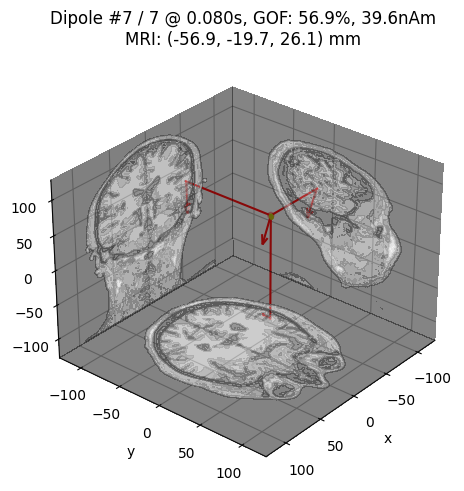

In [16]:
fig= dip[0].plot_locations(fname_trans, 'sample', subjects_dir, mode='orthoview')
# fig= dip[0].plot_locations(fname_trans, 'sample', subjects_dir, mode='outlines')


NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
MRI transform     : /Users/dkleeva/mne_data/MNE-sample-data/MEG/sample/sample_audvis_raw-trans.fif
Head origin       :   -4.3   18.4   67.0 mm rad =   71.8 mm.
Guess grid        :   20.0 mm
Guess mindist     :    5.0 mm
Guess exclude     :   20.0 mm
Using normal MEG coil definitions.
Noise covariance  : /Users/dkleeva/mne_data/MNE-sample-data/MEG/sample/sample_audvis-cov.fif

Coordinate transformation: MRI (surface RAS) -> head
    0.999310 0.009985 -0.035787      -3.17 mm
    0.012759 0.812405 0.582954       6.86 mm
    0.034894 -0.583008 0.811716      28.88 mm
    0.000000 0.000000 0.000000       1.00
Coordinate transformation: MEG device -> head
    0.991420 -0.039936 -0.124467      -6.13 mm
    0.060661 0.984012 0.167456       0.06 mm
    0.115790 -0.173570 0.977991      64.74 mm
    0.000000 0.000000 0.000000       1.00
0 bad channels total
Read 102 MEG channels from info
105 coil definitions read
Coordin

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]

---- Fitted :    69.9 ms, distance to inner skull : 10.7727 mm


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]

---- Fitted :    71.6 ms, distance to inner skull : 10.8639 mm


...

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]

---- Fitted :    78.3 ms, distance to inner skull : 10.9771 mm


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]

---- Fitted :    79.9 ms, distance to inner skull : 10.9913 mm
Projections have already been applied. Setting proj attribute to True.
7 time points fitted


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]

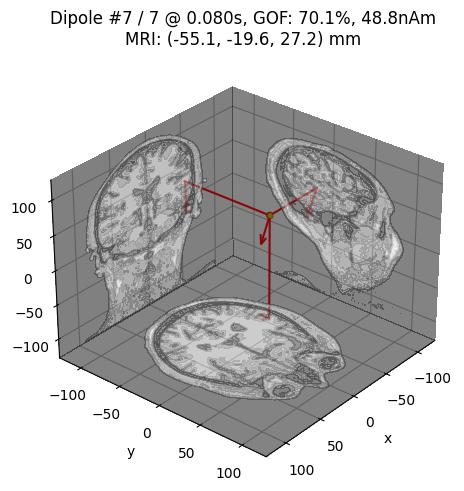

In [17]:
evoked.pick_types(meg='mag', eeg=False)
dip = mne.fit_dipole(evoked, fname_cov, fname_bem, fname_trans)
fig= dip[0].plot_locations(fname_trans, 'sample', subjects_dir, mode='orthoview')

Reading /Users/dkleeva/mne_data/MNE-sample-data/MEG/sample/sample_audvis-ave.fif ...
    Read a total of 4 projection items:
        PCA-v1 (1 x 102) active
        PCA-v2 (1 x 102) active
        PCA-v3 (1 x 102) active
        Average EEG reference (1 x 60) active
    Found the data of interest:
        t =    -199.80 ...     499.49 ms (Right Auditory)
        0 CTF compensation matrices available
        nave = 61 - aspect type = 100
Projections have already been applied. Setting proj attribute to True.
Applying baseline correction (mode: mean)
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
MRI transform     : /Users/dkleeva/mne_data/MNE-sample-data/MEG/sample/sample_audvis_raw-trans.fif
Head origin       :   -4.3   18.4   67.0 mm rad =   71.8 mm.
Guess grid        :   20.0 mm
Guess mindist     :    5.0 mm
Guess exclude     :   20.0 mm
Using normal MEG coil definitions.
Noise covariance  : /Users/dkleeva/mne_data/MNE-sample-data/MEG/sample/sample_audvis

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


[done 156 sources]


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]

---- Fitted :    69.9 ms, distance to inner skull : 10.8966 mm


...

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]

---- Fitted :    78.3 ms, distance to inner skull : 10.5287 mm


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]

---- Fitted :    79.9 ms, distance to inner skull : 10.3204 mm
No projector specified for this dataset. Please consider the method self.add_proj.
7 time points fitted


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]

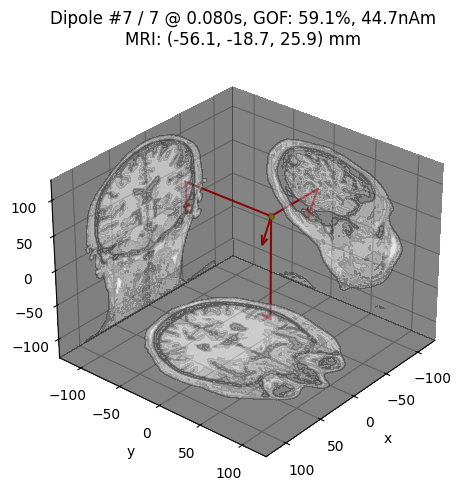

In [18]:
evoked = mne.read_evokeds(fname_ave, condition='Right Auditory',
                          baseline=(None, 0))
evoked.pick_types(meg='grad', eeg=False)
evoked_full = evoked.copy()
evoked.crop(0.07, 0.08)
dip = mne.fit_dipole(evoked, fname_cov, fname_bem, fname_trans)
fig= dip[0].plot_locations(fname_trans, 'sample', subjects_dir, mode='orthoview')


## Prediction VS Observation

In [19]:
evoked = mne.read_evokeds(fname_ave, condition='Right Auditory',
                          baseline=(None, 0))
evoked.pick_types(meg=True, eeg=False)
evoked_full = evoked.copy()
evoked.crop(0.07, 0.08)
dip = mne.fit_dipole(evoked, fname_cov, fname_bem, fname_trans)

Reading /Users/dkleeva/mne_data/MNE-sample-data/MEG/sample/sample_audvis-ave.fif ...
    Read a total of 4 projection items:
        PCA-v1 (1 x 102) active
        PCA-v2 (1 x 102) active
        PCA-v3 (1 x 102) active
        Average EEG reference (1 x 60) active
    Found the data of interest:
        t =    -199.80 ...     499.49 ms (Right Auditory)
        0 CTF compensation matrices available
        nave = 61 - aspect type = 100
Projections have already been applied. Setting proj attribute to True.
Applying baseline correction (mode: mean)
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
MRI transform     : /Users/dkleeva/mne_data/MNE-sample-data/MEG/sample/sample_audvis_raw-trans.fif
Head origin       :   -4.3   18.4   67.0 mm rad =   71.8 mm.
Guess grid        :   20.0 mm
Guess mindist     :    5.0 mm
Guess exclude     :   20.0 mm
Using normal MEG coil definitions.
Noise covariance  : /Users/dkleeva/mne_data/MNE-sample-data/MEG/sample/sample_audvis

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


[done 156 sources]


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]

---- Fitted :    69.9 ms, distance to inner skull : 10.7310 mm


...

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]

---- Fitted :    78.3 ms, distance to inner skull : 9.7447 mm


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]

---- Fitted :    79.9 ms, distance to inner skull : 9.4527 mm
Projections have already been applied. Setting proj attribute to True.
7 time points fitted


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]

In [20]:
dip = dip[0]
dip

<Dipole | n_times : 7, tmin : 0.070, tmax : 0.080>

In [21]:
fwd, stc = make_forward_dipole(dip, fname_bem, evoked.info, fname_trans)
pred_evoked = simulate_evoked(fwd, stc, evoked.info, cov=None, nave=np.inf)


Positions (in meters) and orientations
7 sources
Source space          : <SourceSpaces: [<discrete, n_used=7>] head coords, ~3 kB>
MRI -> head transform : /Users/dkleeva/mne_data/MNE-sample-data/MEG/sample/sample_audvis_raw-trans.fif
Measurement data      : instance of Info
Conductor model   : /Users/dkleeva/mne_data/MNE-sample-data/subjects/sample/bem/sample-5120-bem-sol.fif
Accurate field computations
Do computations in head coordinates
Free source orientations

Read 1 source spaces a total of 7 active source locations

Coordinate transformation: MRI (surface RAS) -> head
    0.999310 0.009985 -0.035787      -3.17 mm
    0.012759 0.812405 0.582954       6.86 mm
    0.034894 -0.583008 0.811716      28.88 mm
    0.000000 0.000000 0.000000       1.00

Read 305 MEG channels from info
105 coil definitions read
Coordinate transformation: MEG device -> head
    0.991420 -0.039936 -0.124467      -6.13 mm
    0.060661 0.984012 0.167456       0.06 mm
    0.115790 -0.173570 0.977991      64.74 

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.3s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.3s finished


Computing MEG at 7 source locations (free orientations)...

Finished.
    Changing to fixed-orientation forward solution with surface-based source orientations...
    [done]
Projecting source estimate to sensor space...
[done]


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.3s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


In [22]:
pred_evoked

<Evoked | '' (average, N=1), 0.069928 – 0.079918 s, baseline off, 305 ch, ~3.2 MB>

No projector specified for this dataset. Please consider the method self.add_proj.


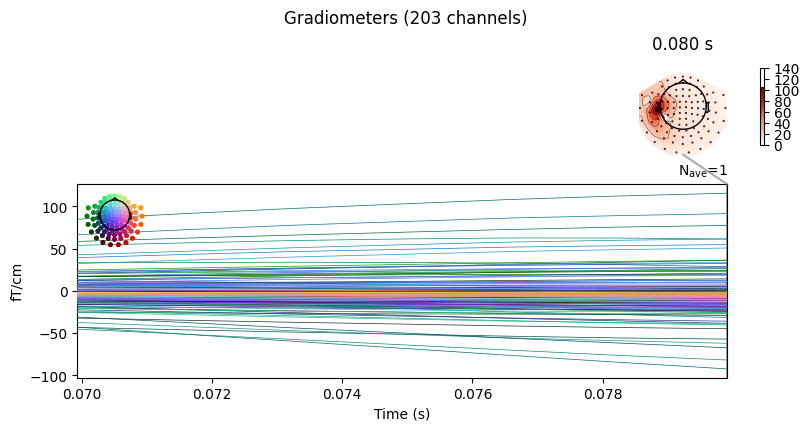

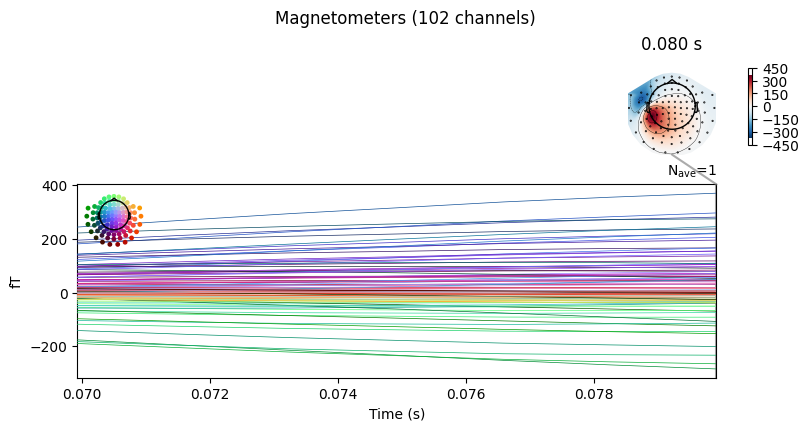

In [23]:
fig = pred_evoked.plot_joint()

In [24]:
best_idx = np.argmax(dip.gof)
best_time = dip.times[best_idx]

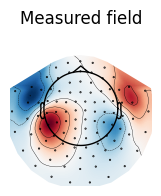

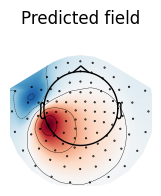

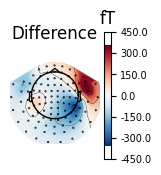

In [25]:
vmin, vmax = -400, 400 

plot_params = dict(times=best_time, ch_type='mag', outlines='head',
                   colorbar=False)
evoked.plot_topomap(time_format='Measured field', **plot_params)

pred_evoked.plot_topomap(time_format='Predicted field',
                         **plot_params)

diff = combine_evoked([evoked, pred_evoked], weights=[1, -1])
plot_params['colorbar'] = True
diff.plot_topomap(time_format='Difference', **plot_params)
plt.show()

## Vizualization

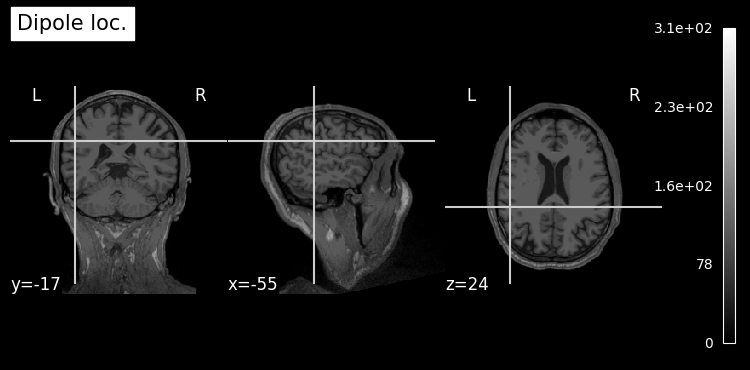

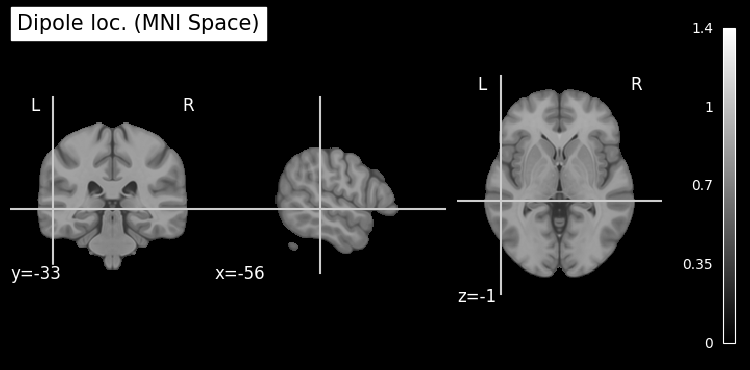

In [26]:
trans = mne.read_trans(fname_trans)
subject = 'sample'
mni_pos = mne.head_to_mni(dip[0].pos, mri_head_t=trans,
                          subject=subject, subjects_dir=subjects_dir)

mri_pos = mne.head_to_mri(dip[0].pos, mri_head_t=trans,
                          subject=subject, subjects_dir=subjects_dir)

t1_fname = op.join(subjects_dir, subject, 'mri', 'T1.mgz')
fig_T1 = plot_anat(t1_fname, cut_coords=mri_pos[0], title='Dipole loc.')

template = load_mni152_template()
fig_template = plot_anat(template, cut_coords=mni_pos[0],
                         title='Dipole loc. (MNI Space)')

## Estimate the time courses

In [27]:
dip[0].gof

array([46.8669251])

In [28]:
best_idx = np.argmax(dip[0].gof)
best_time = dip[0].times[best_idx]

In [29]:
best_time

np.float64(0.06992832460543576)

MRI transform     : /Users/dkleeva/mne_data/MNE-sample-data/MEG/sample/sample_audvis_raw-trans.fif
Head origin       :   -4.3   18.4   67.0 mm rad =   71.8 mm.
Fixed position    :  -59.8    6.1   57.2 mm
Fixed orientation  : 0.0321 -0.6068 -0.7942 mm
Noise covariance  : /Users/dkleeva/mne_data/MNE-sample-data/MEG/sample/sample_audvis-cov.fif

Coordinate transformation: MRI (surface RAS) -> head
    0.999310 0.009985 -0.035787      -3.17 mm
    0.012759 0.812405 0.582954       6.86 mm
    0.034894 -0.583008 0.811716      28.88 mm
    0.000000 0.000000 0.000000       1.00
Coordinate transformation: MEG device -> head
    0.991420 -0.039936 -0.124467      -6.13 mm
    0.060661 0.984012 0.167456       0.06 mm
    0.115790 -0.173570 0.977991      64.74 mm
    0.000000 0.000000 0.000000       1.00
0 bad channels total
Read 305 MEG channels from info
105 coil definitions read
Coordinate transformation: MEG device -> head
    0.991420 -0.039936 -0.124467      -6.13 mm
    0.060661 0.984012 0.1

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 421 out of 421 | elapsed:    0.0s finished


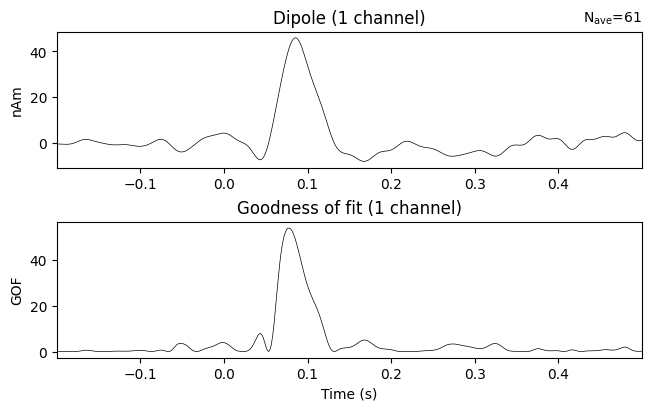

In [30]:
dip_fixed = mne.fit_dipole(evoked_full, fname_cov, fname_bem, fname_trans,
                           pos=dip[0].pos[best_idx], ori=dip[0].ori[best_idx])
fig=dip_fixed[0].plot(time_unit='s')

## XFit

In [31]:
meg_path = data_path / 'MEG' / 'sample'
raw_fname = meg_path / 'sample_audvis_raw.fif'
cov_fname = meg_path / 'sample_audvis-shrunk-cov.fif'
bem_dir = data_path / 'subjects' / 'sample' / 'bem'
bem_fname = bem_dir / 'sample-5120-5120-5120-bem-sol.fif'

In [32]:
raw = mne.io.read_raw_fif(raw_fname)
raw = raw.pick_types(meg=True, eog=True, stim=True)

events = mne.find_events(raw)
event_id = dict(right=1, left=2)
epochs = mne.Epochs(raw, events, event_id,
                    tmin=-0.1, tmax=0.3, baseline=(None, 0),
                    reject=dict(mag=4e-12, grad=4000e-13, eog=150e-6))
epochs.load_data()

epochs.pick('mag')
info=epochs.info

cov = mne.read_cov(cov_fname)
bem = mne.read_bem_solution(bem_fname)

evoked_left = epochs['left'].average()
evoked_right = epochs['right'].average()

Opening raw data file /Users/dkleeva/mne_data/MNE-sample-data/MEG/sample/sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
320 events found on stim channel STI 014
Event IDs: [ 1  2  3  4  5 32]
Not setting metadata
145 matching events found
Setting baseline interval to [-0.09989760657919393, 0.0] s
Applying baseline correction (mode: mean)
Created an SSP operator (subspace dimension = 3)
3 projection items activated
Loading data for 145 events and 241 original time points ...
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on MAG : ['MEG 1711']
    Rejecting  epoch bas

Projections have already been applied. Setting proj attribute to True.


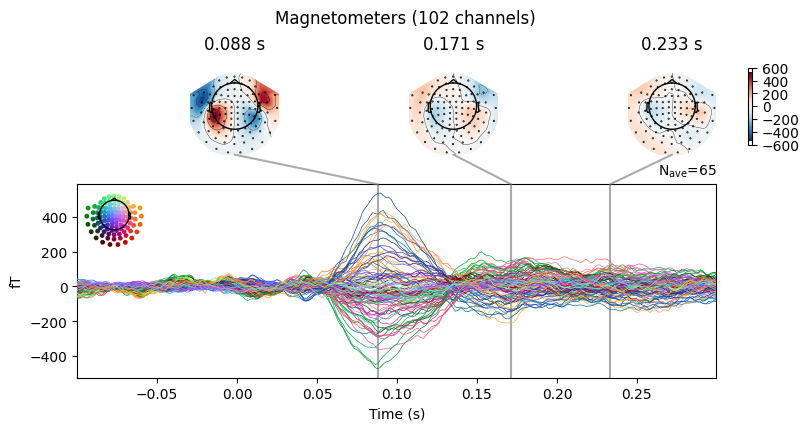

Projections have already been applied. Setting proj attribute to True.


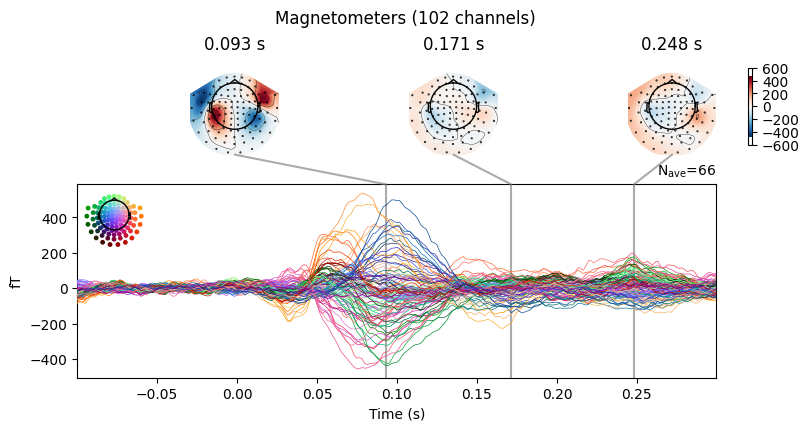

In [33]:
fig = evoked_left.plot_joint()
fig = evoked_right.plot_joint()

In [34]:
info

<Info | 20 non-empty values
 acq_pars: ACQch001 110113 ACQch002 110112 ACQch003 110111 ACQch004 110122 ...
 bads: []
 ch_names: MEG 0111, MEG 0121, MEG 0131, MEG 0141, MEG 0211, MEG 0221, MEG ...
 chs: 102 Magnetometers
 custom_ref_applied: False
 description: acquisition (megacq) VectorView system at NMR-MGH
 dev_head_t: MEG device -> head transform
 dig: 146 items (3 Cardinal, 4 HPI, 61 EEG, 78 Extra)
 events: 1 item (list)
 experimenter: MEG
 file_id: 4 items (dict)
 highpass: 0.1 Hz
 hpi_meas: 1 item (list)
 hpi_results: 1 item (list)
 lowpass: 172.2 Hz
 meas_date: 2002-12-03 19:01:10 UTC
 meas_id: 4 items (dict)
 nchan: 102
 proj_id: 1 item (ndarray)
 proj_name: test
 projs: PCA-v1: on, PCA-v2: on, PCA-v3: on
 sfreq: 600.6 Hz
>

In [35]:
picks_left = mne.read_vectorview_selection('Left', info=info)
picks_left = [ch for ch in picks_left if ch in evoked_left.info['ch_names']]
evoked_fit_left = evoked_left.copy().crop(0.08, 0.08)
evoked_fit_left.pick_channels(picks_left)
cov_fit_left = cov.copy().pick_channels(picks_left)

picks_right = mne.read_vectorview_selection('Right', info=info)
picks_right = [ch for ch in picks_right if ch in evoked_right.info['ch_names']]
evoked_fit_right = evoked_right.copy().crop(0.08, 0.08)
evoked_fit_right.pick_channels(picks_right)
cov_fit_right = cov.copy().pick_channels(picks_right)

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


In [36]:
picks_left

['MEG 0111',
 'MEG 0121',
 'MEG 0131',
 'MEG 0141',
 'MEG 0211',
 'MEG 0221',
 'MEG 0231',
 'MEG 0241',
 'MEG 0311',
 'MEG 0321',
 'MEG 0331',
 'MEG 0341',
 'MEG 0411',
 'MEG 0421',
 'MEG 0431',
 'MEG 0441',
 'MEG 0511',
 'MEG 0521',
 'MEG 0531',
 'MEG 0541',
 'MEG 0611',
 'MEG 0621',
 'MEG 0631',
 'MEG 0641',
 'MEG 0711',
 'MEG 0741',
 'MEG 0821',
 'MEG 1511',
 'MEG 1521',
 'MEG 1531',
 'MEG 1541',
 'MEG 1611',
 'MEG 1621',
 'MEG 1631',
 'MEG 1641',
 'MEG 1711',
 'MEG 1721',
 'MEG 1731',
 'MEG 1741',
 'MEG 1811',
 'MEG 1821',
 'MEG 1831',
 'MEG 1841',
 'MEG 1911',
 'MEG 1921',
 'MEG 1931',
 'MEG 1941',
 'MEG 2011',
 'MEG 2041',
 'MEG 2111',
 'MEG 2141']

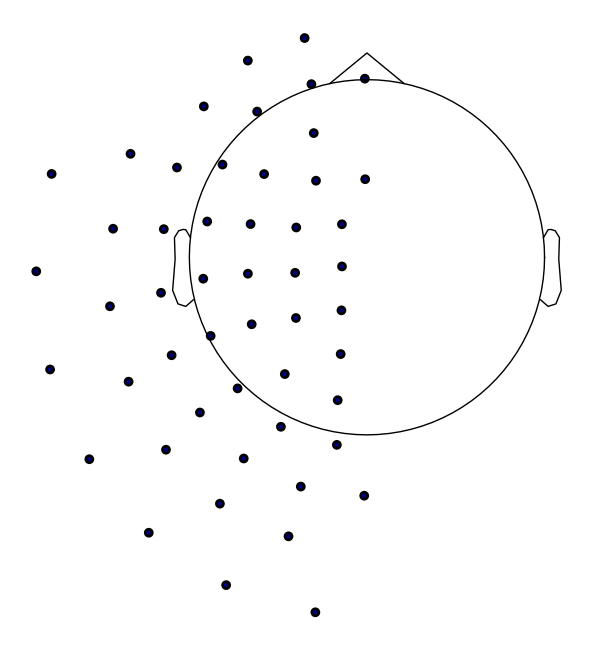

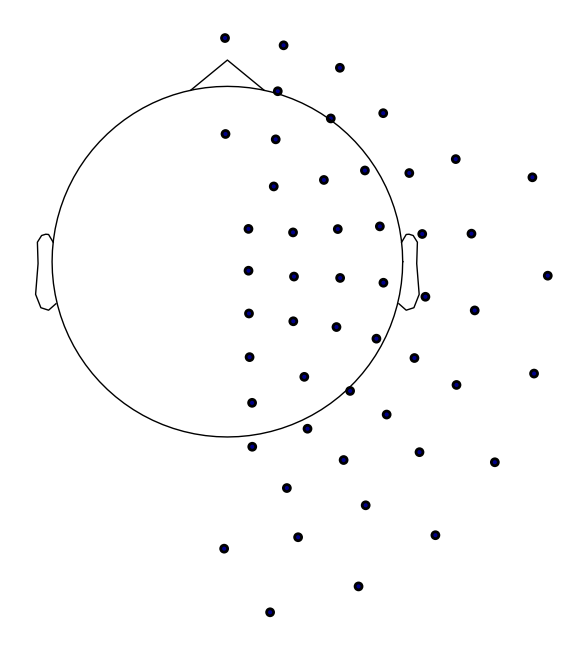

In [37]:
fig = evoked_fit_left.plot_sensors()
fig = evoked_fit_right.plot_sensors()

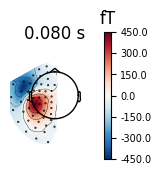

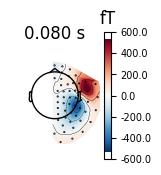

In [38]:
fig = evoked_fit_left.plot_topomap([evoked_fit_left.times[0]])
fig = evoked_fit_right.plot_topomap([evoked_fit_left.times[0]])

In [39]:
dip_left, _ = mne.fit_dipole(evoked_fit_left, cov_fit_left, bem)
dip_right, _ = mne.fit_dipole(evoked_fit_right, cov_fit_right, bem)

BEM               : <ConductorModel | BEM (3 layers) solver=mne>
MRI transform     : identity
Head origin       :    0.4  -12.9   37.7 mm rad =   71.8 mm.
Guess grid        :   20.0 mm
Guess mindist     :    5.0 mm
Guess exclude     :   20.0 mm
Using normal MEG coil definitions.
Noise covariance  : <Covariance | kind : full, shape : (51, 51), range : [-1.7e-26, +6.5e-26], n_samples : 38720>

Coordinate transformation: MRI (surface RAS) -> head
    1.000000 0.000000 0.000000       0.00 mm
    0.000000 1.000000 0.000000       0.00 mm
    0.000000 0.000000 1.000000       0.00 mm
    0.000000 0.000000 0.000000       1.00
Coordinate transformation: MEG device -> head
    0.991420 -0.039936 -0.124467      -6.13 mm
    0.060661 0.984012 0.167456       0.06 mm
    0.115790 -0.173570 0.977991      64.74 mm
    0.000000 0.000000 0.000000       1.00
0 bad channels total
Read 51 MEG channels from info
105 coil definitions read
Coordinate transformation: MEG device -> head
    0.991420 -0.039936 -0

/var/folders/x7/j3l1lskn5hs7tzf40r9kb7qh0000gn/T/ipykernel_58447/2812180915.py:1: RuntimeWarning: Projection vector 'PCA-v1' has been reduced to 69.79% of its original magnitude by subselecting 51/102 of the original channels. If the ignored channels were bad during SSP computation, we recommend recomputing proj (via compute_proj_raw or related functions) with the bad channels properly marked, because computing SSP with bad channels present in the data but unmarked is dangerous (it can bias the PCA used by SSP). On the other hand, if you know that all channels were good during SSP computation, you can safely use info.normalize_proj() to suppress this warning during projection.
  dip_left, _ = mne.fit_dipole(evoked_fit_left, cov_fit_left, bem)
/var/folders/x7/j3l1lskn5hs7tzf40r9kb7qh0000gn/T/ipykernel_58447/2812180915.py:1: RuntimeWarning: Projection vector 'PCA-v2' has been reduced to 65.94% of its original magnitude by subselecting 51/102 of the original channels. If the ignored chann

[done 156 sources]


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
/var/folders/x7/j3l1lskn5hs7tzf40r9kb7qh0000gn/T/ipykernel_58447/2812180915.py:1: RuntimeWarning: Projection vector 'PCA-v1' has been reduced to 69.79% of its original magnitude by subselecting 51/102 of the original channels. If the ignored channels were bad during SSP computation, we recommend recomputing proj (via compute_proj_raw or related functions) with the bad channels properly marked, because computing SSP with bad channels present in the data but unmarked is dangerous (it can bias the PCA used by SSP). On the other hand, if you know that all channels were good during SSP computation, you can safely use info.normalize_proj() to suppress this warning during projection.
  dip_left, _ = mne.fit_dipole(evoked_fit_left, cov_fit_left, bem)
/var/folders/x7/j3l1lskn5hs7tzf40r9kb7qh0000gn/T/ipykernel_58447/2812180915.py:1: RuntimeWarning: Projection vector 'PCA-v2' has been reduced to 65.94% of its original magnitude

---- Fitted :    79.9 ms, distance to inner skull : 4.9500 mm
Projections have already been applied. Setting proj attribute to True.
1 time points fitted
BEM               : <ConductorModel | BEM (3 layers) solver=mne>
MRI transform     : identity
Head origin       :    0.4  -12.9   37.7 mm rad =   71.8 mm.
Guess grid        :   20.0 mm
Guess mindist     :    5.0 mm
Guess exclude     :   20.0 mm
Using normal MEG coil definitions.
Noise covariance  : <Covariance | kind : full, shape : (51, 51), range : [-2.7e-26, +9.9e-26], n_samples : 38720>

Coordinate transformation: MRI (surface RAS) -> head
    1.000000 0.000000 0.000000       0.00 mm
    0.000000 1.000000 0.000000       0.00 mm
    0.000000 0.000000 1.000000       0.00 mm
    0.000000 0.000000 0.000000       1.00
Coordinate transformation: MEG device -> head
    0.991420 -0.039936 -0.124467      -6.13 mm
    0.060661 0.984012 0.167456       0.06 mm
    0.115790 -0.173570 0.977991      64.74 mm
    0.000000 0.000000 0.000000       

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.5s finished
/var/folders/x7/j3l1

[done 156 sources]


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
/var/folders/x7/j3l1lskn5hs7tzf40r9kb7qh0000gn/T/ipykernel_58447/2812180915.py:2: RuntimeWarning: Projection vector 'PCA-v1' has been reduced to 71.62% of its original magnitude by subselecting 51/102 of the original channels. If the ignored channels were bad during SSP computation, we recommend recomputing proj (via compute_proj_raw or related functions) with the bad channels properly marked, because computing SSP with bad channels present in the data but unmarked is dangerous (it can bias the PCA used by SSP). On the other hand, if you know that all channels were good during SSP computation, you can safely use info.normalize_proj() to suppress this warning during projection.
  dip_right, _ = mne.fit_dipole(evoked_fit_right, cov_fit_right, bem)
/var/folders/x7/j3l1lskn5hs7tzf40r9kb7qh0000gn/T/ipykernel_58447/2812180915.py:2: RuntimeWarning: Projection vector 'PCA-v2' has been reduced to 75.18% of its original magnit

---- Fitted :    79.9 ms, distance to inner skull : 5.0009 mm
Projections have already been applied. Setting proj attribute to True.
1 time points fitted


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.4s finished


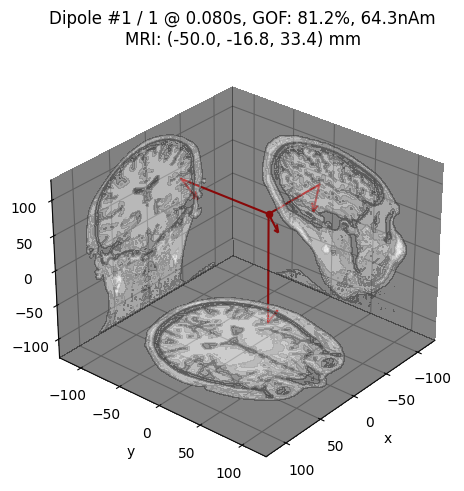

In [40]:
fig= dip_left[0].plot_locations(fname_trans, 'sample', subjects_dir, mode='orthoview')

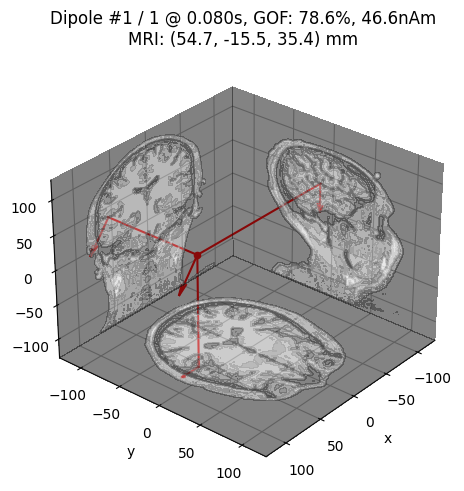

In [41]:
fig= dip_right[0].plot_locations(fname_trans, 'sample', subjects_dir, mode='orthoview')

MRI transform     : /Users/dkleeva/mne_data/MNE-sample-data/MEG/sample/sample_audvis_raw-trans.fif
Head origin       :   -4.3   18.4   67.0 mm rad =   71.8 mm.
Fixed position    :  -54.5   12.0   64.1 mm
Fixed orientation  : -0.4360 -0.6285 -0.6441 mm
Noise covariance  : /Users/dkleeva/mne_data/MNE-sample-data/MEG/sample/sample_audvis-cov.fif

Coordinate transformation: MRI (surface RAS) -> head
    0.999310 0.009985 -0.035787      -3.17 mm
    0.012759 0.812405 0.582954       6.86 mm
    0.034894 -0.583008 0.811716      28.88 mm
    0.000000 0.000000 0.000000       1.00
Coordinate transformation: MEG device -> head
    0.991420 -0.039936 -0.124467      -6.13 mm
    0.060661 0.984012 0.167456       0.06 mm
    0.115790 -0.173570 0.977991      64.74 mm
    0.000000 0.000000 0.000000       1.00
0 bad channels total
Read 305 MEG channels from info
105 coil definitions read
Coordinate transformation: MEG device -> head
    0.991420 -0.039936 -0.124467      -6.13 mm
    0.060661 0.984012 0.

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 421 out of 421 | elapsed:    0.0s finished


[done 1 source]
Projections have already been applied. Setting proj attribute to True.
421 time points fitted


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 421 out of 421 | elapsed:    0.0s finished


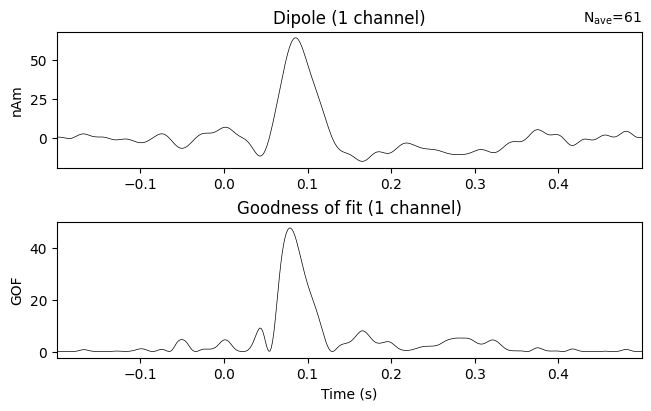

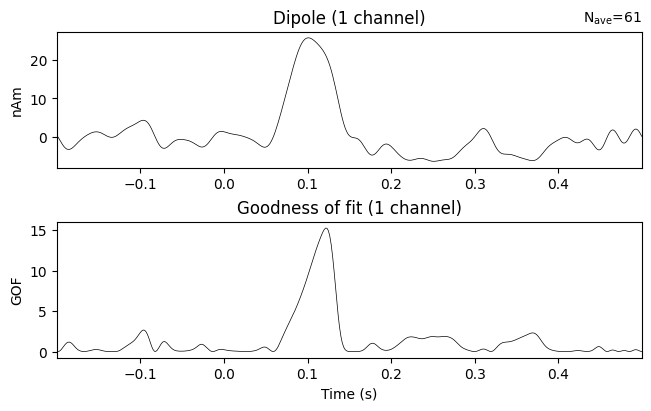

In [42]:
best_idx = np.argmax(dip_left[0].gof)
best_time = dip_left[0].times[best_idx]
dip_fixed_left = mne.fit_dipole(evoked_full, fname_cov, fname_bem, fname_trans,
                           pos=dip_left[0].pos[best_idx], ori=dip_left[0].ori[best_idx])
best_idx = np.argmax(dip_right[0].gof)
best_time = dip_right[0].times[best_idx]
dip_fixed_right = mne.fit_dipole(evoked_full, fname_cov, fname_bem, fname_trans,
                           pos=dip_right[0].pos[best_idx], ori=dip_right[0].ori[best_idx])
fig=dip_fixed_left[0].plot(time_unit='s')
fig=dip_fixed_right[0].plot(time_unit='s')

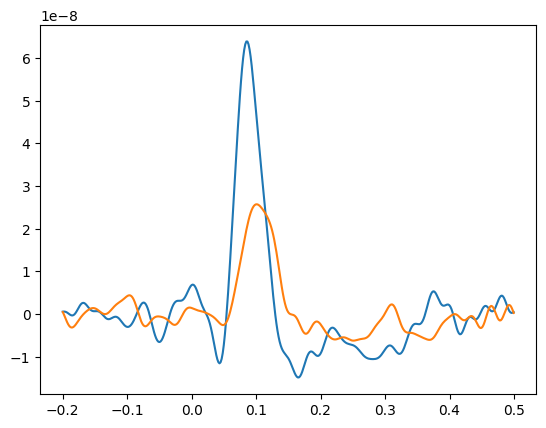

In [43]:
plt.plot(dip_fixed_left[0].times,dip_fixed_left[0].data[0,:])
plt.plot(dip_fixed_right[0].times,dip_fixed_right[0].data[0,:])

Be careful

In [44]:
picks_left = mne.read_vectorview_selection('Left-occipital', info=info)
picks_left = [ch for ch in picks_left if ch in evoked_left.info['ch_names']]
evoked_fit_left = evoked_left.copy().crop(0.08, 0.08)
evoked_fit_left.pick_channels(picks_left)
cov_fit_left = cov.copy().pick_channels(picks_left)

picks_right = mne.read_vectorview_selection('Right-occipital', info=info)
picks_right = [ch for ch in picks_right if ch in evoked_right.info['ch_names']]
evoked_fit_right = evoked_right.copy().crop(0.08, 0.08)
evoked_fit_right.pick_channels(picks_right)
cov_fit_right = cov.copy().pick_channels(picks_right)

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


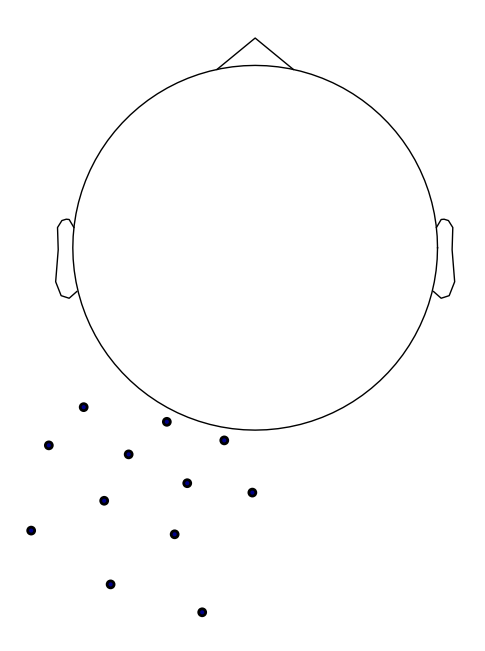

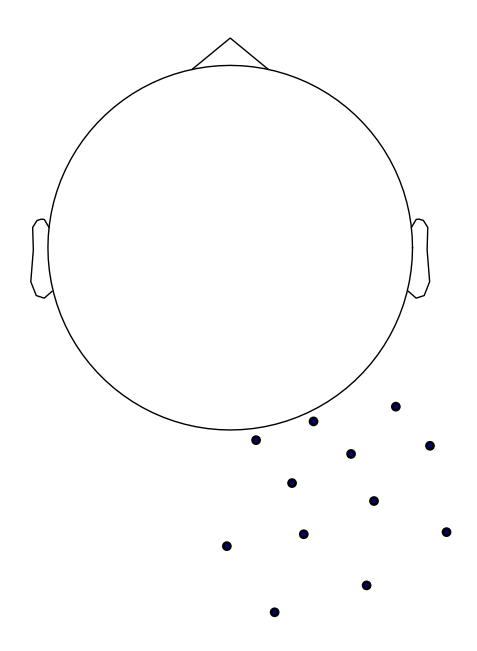

In [45]:
fig = evoked_fit_left.plot_sensors()
fig = evoked_fit_right.plot_sensors()

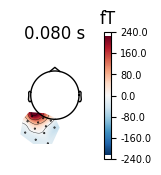

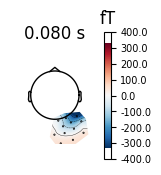

In [46]:
fig = evoked_fit_left.plot_topomap([evoked_fit_left.times[0]])
fig = evoked_fit_right.plot_topomap([evoked_fit_left.times[0]])

In [47]:
dip_left, _ = mne.fit_dipole(evoked_fit_left, cov_fit_left, bem)
dip_right, _ = mne.fit_dipole(evoked_fit_right, cov_fit_right, bem)

BEM               : <ConductorModel | BEM (3 layers) solver=mne>
MRI transform     : identity
Head origin       :    0.4  -12.9   37.7 mm rad =   71.8 mm.
Guess grid        :   20.0 mm
Guess mindist     :    5.0 mm
Guess exclude     :   20.0 mm
Using normal MEG coil definitions.
Noise covariance  : <Covariance | kind : full, shape : (12, 12), range : [-3.2e-27, +4.8e-26], n_samples : 38720>

Coordinate transformation: MRI (surface RAS) -> head
    1.000000 0.000000 0.000000       0.00 mm
    0.000000 1.000000 0.000000       0.00 mm
    0.000000 0.000000 1.000000       0.00 mm
    0.000000 0.000000 0.000000       1.00
Coordinate transformation: MEG device -> head
    0.991420 -0.039936 -0.124467      -6.13 mm
    0.060661 0.984012 0.167456       0.06 mm
    0.115790 -0.173570 0.977991      64.74 mm
    0.000000 0.000000 0.000000       1.00
0 bad channels total
Read 12 MEG channels from info
105 coil definitions read
Coordinate transformation: MEG device -> head
    0.991420 -0.039936 -0

/var/folders/x7/j3l1lskn5hs7tzf40r9kb7qh0000gn/T/ipykernel_58447/2812180915.py:1: RuntimeWarning: Projection vector 'PCA-v1' has been reduced to 52.75% of its original magnitude by subselecting 12/102 of the original channels. If the ignored channels were bad during SSP computation, we recommend recomputing proj (via compute_proj_raw or related functions) with the bad channels properly marked, because computing SSP with bad channels present in the data but unmarked is dangerous (it can bias the PCA used by SSP). On the other hand, if you know that all channels were good during SSP computation, you can safely use info.normalize_proj() to suppress this warning during projection.
  dip_left, _ = mne.fit_dipole(evoked_fit_left, cov_fit_left, bem)
/var/folders/x7/j3l1lskn5hs7tzf40r9kb7qh0000gn/T/ipykernel_58447/2812180915.py:1: RuntimeWarning: Projection vector 'PCA-v2' has been reduced to 10.74% of its original magnitude by subselecting 12/102 of the original channels. If the ignored chann

---- Fitted :    79.9 ms, distance to inner skull : 4.9894 mm
Projections have already been applied. Setting proj attribute to True.
1 time points fitted
BEM               : <ConductorModel | BEM (3 layers) solver=mne>
MRI transform     : identity


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]

Head origin       :    0.4  -12.9   37.7 mm rad =   71.8 mm.
Guess grid        :   20.0 mm
Guess mindist     :    5.0 mm
Guess exclude     :   20.0 mm
Using normal MEG coil definitions.
Noise covariance  : <Covariance | kind : full, shape : (12, 12), range : [-5.1e-27, +3.4e-26], n_samples : 38720>

Coordinate transformation: MRI (surface RAS) -> head
    1.000000 0.000000 0.000000       0.00 mm
    0.000000 1.000000 0.000000       0.00 mm
    0.000000 0.000000 1.000000       0.00 mm
    0.000000 0.000000 0.000000       1.00
Coordinate transformation: MEG device -> head
    0.991420 -0.039936 -0.124467      -6.13 mm
    0.060661 0.984012 0.167456       0.06 mm
    0.115790 -0.173570 0.977991      64.74 mm
    0.000000 0.000000 0.000000       1.00
0 bad channels total
Read 12 MEG channels from info
105 coil definitions read
Coordinate transformation: MEG device -> head
    0.991420 -0.039936 -0.124467      -6.13 mm
    0.060661 0.984012 0.167456       0.06 mm
    0.115790 -0.173570 0.97

/var/folders/x7/j3l1lskn5hs7tzf40r9kb7qh0000gn/T/ipykernel_58447/2812180915.py:2: RuntimeWarning: Projection vector 'PCA-v1' has been reduced to 52.80% of its original magnitude by subselecting 12/102 of the original channels. If the ignored channels were bad during SSP computation, we recommend recomputing proj (via compute_proj_raw or related functions) with the bad channels properly marked, because computing SSP with bad channels present in the data but unmarked is dangerous (it can bias the PCA used by SSP). On the other hand, if you know that all channels were good during SSP computation, you can safely use info.normalize_proj() to suppress this warning during projection.
  dip_right, _ = mne.fit_dipole(evoked_fit_right, cov_fit_right, bem)
/var/folders/x7/j3l1lskn5hs7tzf40r9kb7qh0000gn/T/ipykernel_58447/2812180915.py:2: RuntimeWarning: Projection vector 'PCA-v2' has been reduced to 13.03% of its original magnitude by subselecting 12/102 of the original channels. If the ignored ch

[done 156 sources]


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
/var/folders/x7/j3l1lskn5hs7tzf40r9kb7qh0000gn/T/ipykernel_58447/2812180915.py:2: RuntimeWarning: Projection vector 'PCA-v1' has been reduced to 52.80% of its original magnitude by subselecting 12/102 of the original channels. If the ignored channels were bad during SSP computation, we recommend recomputing proj (via compute_proj_raw or related functions) with the bad channels properly marked, because computing SSP with bad channels present in the data but unmarked is dangerous (it can bias the PCA used by SSP). On the other hand, if you know that all channels were good during SSP computation, you can safely use info.normalize_proj() to suppress this warning during projection.
  dip_right, _ = mne.fit_dipole(evoked_fit_right, cov_fit_right, bem)
/var/folders/x7/j3l1lskn5hs7tzf40r9kb7qh0000gn/T/ipykernel_58447/2812180915.py:2: RuntimeWarning: Projection vector 'PCA-v2' has been reduced to 13.03% of its original magnit

---- Fitted :    79.9 ms, distance to inner skull : 4.9611 mm
Projections have already been applied. Setting proj attribute to True.
1 time points fitted


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]

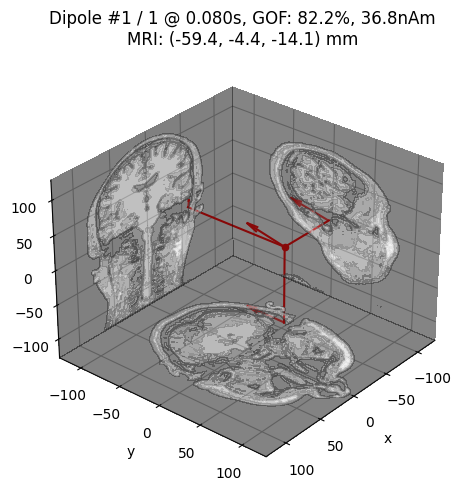

In [48]:
fig= dip_left[0].plot_locations(fname_trans, 'sample', subjects_dir, mode='orthoview')

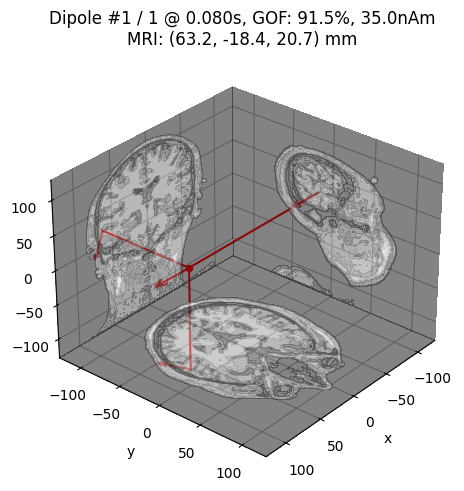

In [49]:
fig= dip_right[0].plot_locations(fname_trans, 'sample', subjects_dir, mode='orthoview')

In [50]:
best_idx = np.argmax(dip_left[0].gof)
best_time = dip_left[0].times[best_idx]
dip_fixed_left = mne.fit_dipole(evoked_full, fname_cov, fname_bem, fname_trans,
                           pos=dip_left[0].pos[best_idx], ori=dip_left[0].ori[best_idx])
best_idx = np.argmax(dip_right[0].gof)
best_time = dip_right[0].times[best_idx]
dip_fixed_right = mne.fit_dipole(evoked_full, fname_cov, fname_bem, fname_trans,
                           pos=dip_right[0].pos[best_idx], ori=dip_right[0].ori[best_idx])
fig=dip_fixed_left[0].plot(time_unit='s')
fig=dip_fixed_right[0].plot(time_unit='s')

MRI transform     : /Users/dkleeva/mne_data/MNE-sample-data/MEG/sample/sample_audvis_raw-trans.fif
Head origin       :   -4.3   18.4   67.0 mm rad =   71.8 mm.
Fixed position    :  -62.1   -5.7   17.9 mm
Fixed orientation  : -0.0386 -0.6537 0.7557 mm
Noise covariance  : /Users/dkleeva/mne_data/MNE-sample-data/MEG/sample/sample_audvis-cov.fif

Coordinate transformation: MRI (surface RAS) -> head
    0.999310 0.009985 -0.035787      -3.17 mm
    0.012759 0.812405 0.582954       6.86 mm
    0.034894 -0.583008 0.811716      28.88 mm
    0.000000 0.000000 0.000000       1.00
Coordinate transformation: MEG device -> head
    0.991420 -0.039936 -0.124467      -6.13 mm
    0.060661 0.984012 0.167456       0.06 mm
    0.115790 -0.173570 0.977991      64.74 mm
    0.000000 0.000000 0.000000       1.00
0 bad channels total
Read 305 MEG channels from info
105 coil definitions read
Coordinate transformation: MEG device -> head
    0.991420 -0.039936 -0.124467      -6.13 mm
    0.060661 0.984012 0.1

ValueError: fixed position is 17.4mm outside the inner skull boundary

In [ ]:
picks_vert = mne.read_vectorview_selection('Vertex', info=info)
picks_vert = [ch for ch in picks_vert if ch in evoked_left.info['ch_names']]
evoked_fit_vert = evoked_left.copy().crop(0.08, 0.08)
evoked_fit_vert.pick_channels(picks_vert)
cov_fit_vert = cov.copy().pick_channels(picks_vert)


In [ ]:
fig = evoked_fit_vert.plot_sensors()

In [ ]:
fig = evoked_fit_vert.plot_topomap([evoked_fit_left.times[0]])

In [ ]:
dip_vert, _ = mne.fit_dipole(evoked_fit_vert, cov_fit_vert, bem)

In [ ]:
fig= dip_vert[0].plot_locations(fname_trans, 'sample', subjects_dir, mode='orthoview')

In [ ]:
best_idx = np.argmax(dip_vert[0].gof)
best_time = dip_vert[0].times[best_idx]
dip_fixed_vert = mne.fit_dipole(evoked_full, fname_cov, fname_bem, fname_trans,
                           pos=dip_vert[0].pos[best_idx], ori=dip_vert[0].ori[best_idx])
fig=dip_fixed_vert[0].plot(time_unit='s')

## RAP MUSIC

In [ ]:
data_path = sample.data_path()
subjects_dir = str(data_path) + '/subjects'
fwd_fname = str(data_path) + '/MEG/sample/sample_audvis-meg-eeg-oct-6-fwd.fif'
evoked_fname = str(data_path) + '/MEG/sample/sample_audvis-ave.fif'
cov_fname = str(data_path) + '/MEG/sample/sample_audvis-cov.fif'

condition = 'Right Auditory'
evoked = mne.read_evokeds(evoked_fname, condition=condition,
                          baseline=(None, 0))
evoked.crop(tmin=0.05, tmax=0.15)

evoked.pick_types(meg=True, eeg=False)

forward = mne.read_forward_solution(fwd_fname)

noise_cov = mne.read_cov(cov_fname)

In [ ]:
dipoles, residual = rap_music(evoked, forward, noise_cov, n_dipoles=2,
                              return_residual=True, verbose=True)

In [ ]:
dipoles

In [ ]:
trans = forward['mri_head_t']
fig = plot_dipole_locations(dipoles[0], trans, 'sample', subjects_dir=subjects_dir)

In [ ]:
fig = evoked.plot_topomap()

In [ ]:
fwd_dip, stc = make_forward_dipole(dipoles, bem, evoked.info, trans)
print(stc)

pred_evoked = simulate_evoked(fwd_dip, stc, evoked.info, cov=None, nave=np.inf)
pred_evoked.plot_topomap()
diff = combine_evoked([evoked, pred_evoked], weights=[1, -1])
fig = diff.plot_topomap()

In [ ]:
fig = plot_dipole_amplitudes(dipoles)
